2장 신경망 모델

In [ ]:
# 예제 2.1 단층 신경망을 이용한 분류 모델(Sequential 방식)

# 셋업
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

# 모델 생성
model = Sequential([
    Input(shape=(4, )),   # 입력 특징 4개
    Dense(2,   # 출력층 뉴런 2개
          use_bias=False,  # 바이어스 사용하지 않음
          name='output_layer')
])

In [1]:
# 예제 2.1 단층 신경망을 이용한 분류 모델(함수형 API 방식)

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense

# 모델 생성
inputs = Input(shape=(4, ))   # 입력 특징 4개
outputs = Dense(2, use_bias=False,    # 출력층 뉴런 2개
                name='output_layer')(inputs)

model = Model(inputs, outputs, name='single_layer_model')

# 모델 구조 확인
model.summary()

Model: "single_layer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 2)                   │               8 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 예제 2.2 3가지 유형으로 분류하는 다층 신경망 모델(Sequential 방식)

# 셋업
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Flatten

# 모델 생성
model = Sequential([
    Input(shape=(9, 7)),   # 입력(9x7)
    Flatten(),   # 2차원 이미지를 1차원 벡터로 변환
    Dense(2, name='hidden_layer'),   # 은닉층 뉴런 2개
    Dense(3, name='output_layer')   # 출력층 뉴런 3개

])

In [ ]:
# 예제 2.2 3가지 유형으로 분류하는 다층 신경망 모델(Sequential model.add 방식)

# 모델 생성
model = Sequential()
model.add(Input(shape=(9, 7)))   # 입력(9x7)
model.add(Flatten())   # 2차원 이미지를 1차원 벡터로 변환
model.add(Dense(2, name='hidden_layer'))   # 은닉층 뉴런 2개
model.add(Dense(3, name='output_layer'))   # 출력층 뉴런 3개

In [ ]:
# 예제 2.2 3가지 유형으로 분류하는 다층 신경망 모델(함수형 API 방식)

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Flatten

# 모델 생성
inputs = Input(shape=(9, 7))   # 입력(9x7)
x = Flatten()(inputs)   # 2차원 이미지를 1차원 벡터로 변환
x = Dense(2, name='hidden_layer')(x)   # 은닉층 뉴런 2개
outputs = Dense(3, name='output_layer')(x)   # 출력층 뉴런 3개

model = Model(inputs, outputs, name='3-layers_model')

# 모델 구조 요약
model.summary()

Model: "3-layers_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 9, 7)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 63)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_layer (Dense)                 │ (None, 2)                   │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 3)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

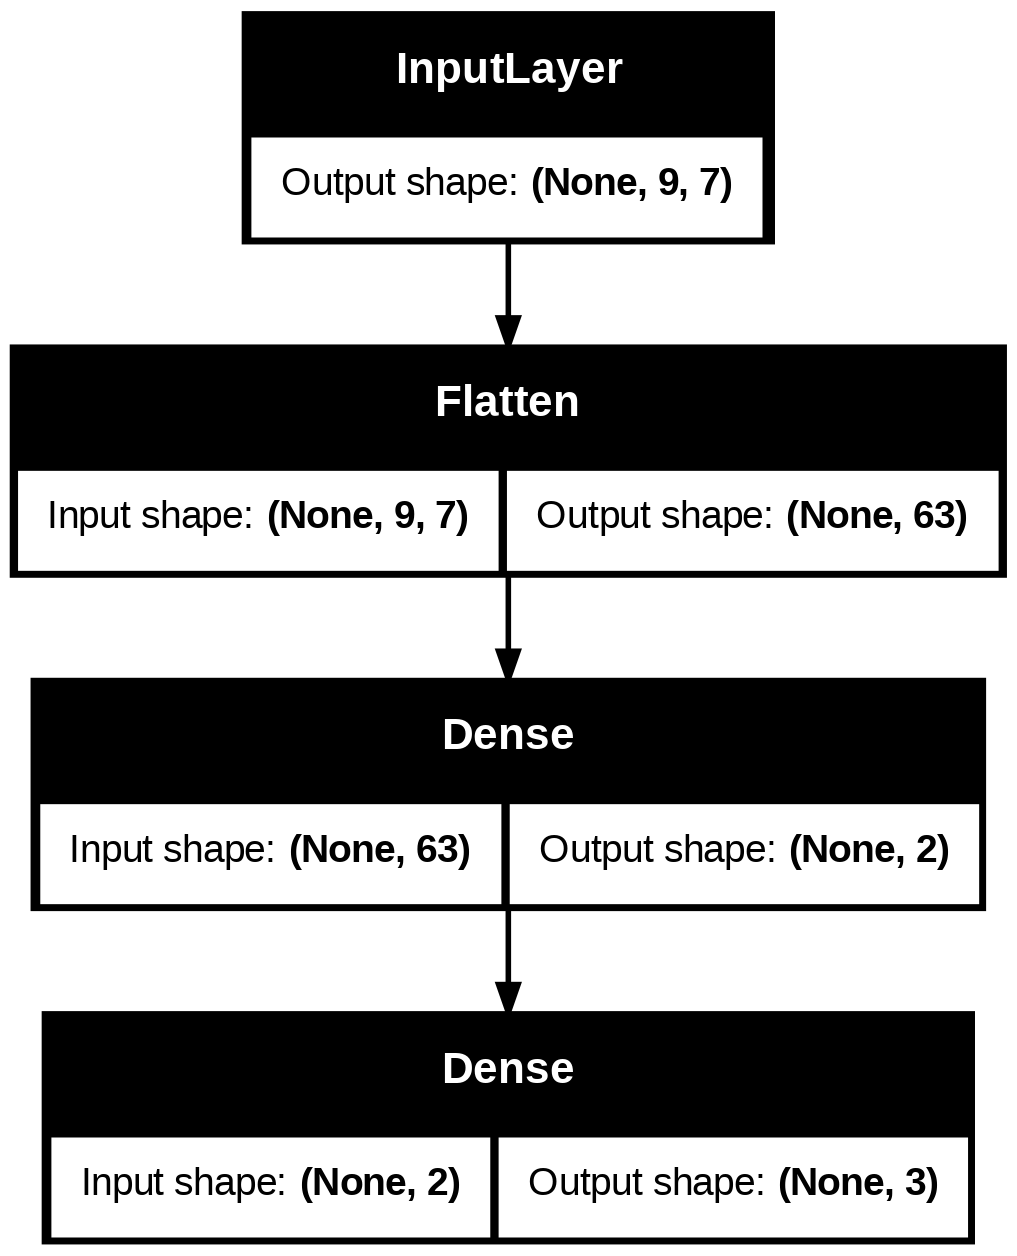

In [ ]:
# 모델 구조 확인
tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
# 예제 2.3 활성화 함수에 의한 뉴런의 출력

import numpy as np

# ReLU 함수 정의
def relu(net):
    if net >= 0:
        return net
    else:
        return 0

# sigmoid 함수 정의
def sigmoid(net):
    return  1 / (1 + np.exp(-net))

# tanh 함수 정의
def tanh(net):
    return (np.exp(net) - np.exp(-net)) / (np.exp(net) + np.exp(-net))

x = np.array([1, 2])   # 입력
w = np.array([-1, 1])   # 가중치

net = np.dot(x, w)   # 입력 가중합

y1 = relu(net)   # ReLU 함수 출력
y2 = sigmoid(net)   # sigmoid 함수 출력
y3 = tanh(net)   # tanh 함수 출력

print(f"net: {net} \n")
print(f"output of ReLU: {y1}")
print(f"output of sigmoid: {y2:.2f}")
print(f"output of tanh: {y3:.2f}")

net: 1 

output of ReLU: 1
output of sigmoid: 0.73
output of tanh: 0.76


In [ ]:
# 예제 2.4 sigmoid 함수와 softmax 함수 출력 비교

import numpy as np

# sigmoid 함수 정의
def sigmoid(net):
    return  1 / (1 + np.exp(-net))

# softmax 함수 정의
def softmax(net):
    return np.exp(net) / np.sum(np.exp(net))

x = np.array([[1, 1, 0]])   # 입력
w = np.array([[1, 2, 3], [3, 2, 1]])   # 가중치

net = np.matmul(x, w.T).reshape(-1)   # 입력 가중합

y1 = sigmoid(net).round(2)   # sigmoid 함수 출력
y2 = softmax(net).round(2)   # softmax 함수 출력

print(f"net: {net} \n")
print(f"y_sigmoid: {y1} \n sum of y_sigmoid: {np.sum(y1).round(2)} \n")
print(f"y_softmax: {y2} \n sum of y_softmax: {np.sum(y2)}")


net: [3 5] 

y_sigmoid: [0.95 0.99] 
 sum of y_sigmoid: 1.94 

y_softmax: [0.12 0.88] 
 sum of y_softmax: 1.0
